<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [13]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 131.9 MB/s eta 0:00:00


In [1]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

try:
    nlp = spacy.load("en_core_web_sm")
except:
    spacy_download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

print("spaCy pipeline:", nlp.pipe_names)
print("NLTK resources and spaCy model ready.")

spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
NLTK resources and spaCy model ready.


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [2]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
print(f"Loaded {len(raw_reviews)} reviews.")

Loaded 10 reviews.


### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [3]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    tokens = word_tokenize(text.lower())
    cleaned_tokens = [
        t for t in tokens
        if t not in string.punctuation and t not in stop_words
    ]
    lemmatized = [lemmatizer.lemmatize(t) for t in cleaned_tokens]
    return " ".join(lemmatized)

### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [4]:
cleaned_reviews = [preprocess_text(rev) for rev in raw_reviews]

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")

RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [9]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [10]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    tokens = word_tokenize(text)
    return pos_tag(tokens)

### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [11]:
sample_texts = raw_reviews[:2]
sample_cleaned = cleaned_reviews[:2]

print("--- NER COMPARISON ---")
for r, c in zip(sample_texts, sample_cleaned):
    print(f"Raw NER: {perform_ner(r)}")
    print(f"Cleaned NER: {perform_ner(c)}\n")

print("--- POS COMPARISON ---")
for r, c in zip(sample_texts, sample_cleaned):
    print(f"Raw POS: {perform_pos_tagging(r)}")
    print(f"Cleaned POS: {perform_pos_tagging(c)}\n")

--- NER COMPARISON ---
Raw NER: [('McDonald', 'ORG')]
Cleaned NER: [("mcdonald 's food ok service", 'ORG')]

Raw NER: [('Japanese', 'NORP')]
Cleaned NER: [('japanese', 'NORP')]

--- POS COMPARISON ---
Raw POS: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
Cleaned POS: [('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]

Raw POS: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]
Cleaned POS: [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]



## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [14]:
from gensim.models import Word2Vec

tokenized_reviews = [rev.split() for rev in cleaned_reviews]

w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=50, window=3, min_count=1, sg=1)
print(w2v_model)

Word2Vec<vocab=56, vector_size=50, alpha=0.025>


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [15]:
print(f"Vector size: {w2v_model.vector_size}")
print(f"Vocabulary size: {len(w2v_model.wv.index_to_key)}")
print(f"Vocabulary: {w2v_model.wv.index_to_key}")

Vector size: 50
Vocabulary size: 56
Vocabulary: ['restaurant', 'sushi', 'pizza', 'service', "'s", 'die', 'treat', 'sweet', 'selection', 'dessert', 'steak', 'excellent', 'atmosphere', 'cozy', 'street', 'main', 'steakhouse', 'flavorful', 'fresh', 'always', 'express', 'slow', 'burnt', 'hut', 'experience', 'terrible', 'delicious', 'dish', 'pasta', 'amazing', 'italia', 'bella', 'ambiance', 'employee', 'google', 'helpful', 'friendly', 'staff', 'option', 'variety', 'wide', 'loving', 'menu', 'summer', 'last', 'thailand', 'traveled', 'loved', 'anyone', 'japanese', 'recommend', 'would', 'bad', 'ok', 'food', 'mcdonald']


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

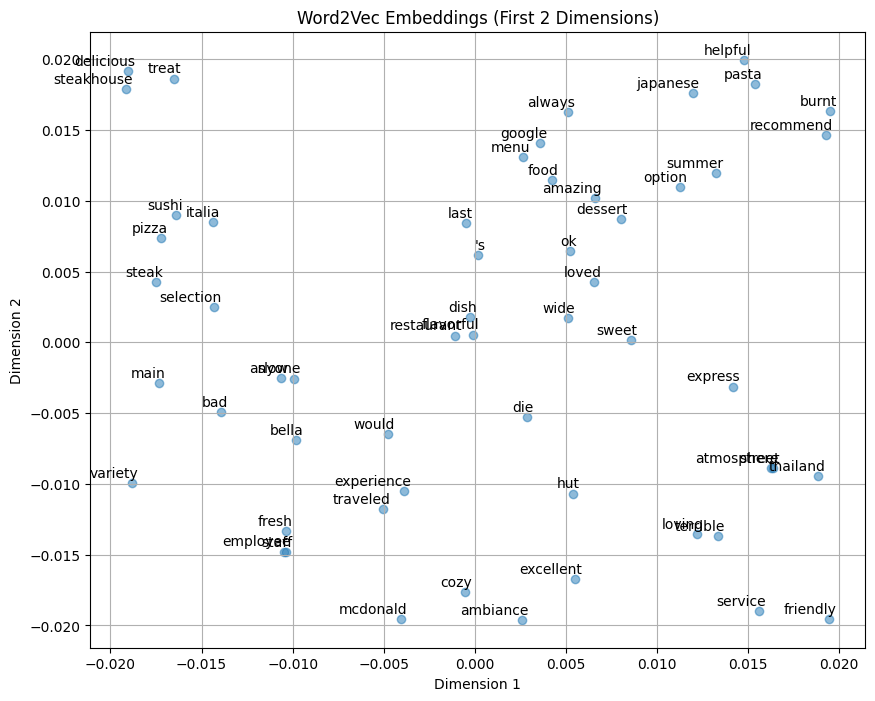

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model):
    words = model.wv.index_to_key
    vectors = model.wv.vectors

    x = vectors[:, 0]
    y = vectors[:, 1]

    plt.figure(figsize=(10, 8))
    plt.scatter(x, y, alpha=0.5)

    for i, word in enumerate(words):
        plt.annotate(word, xy=(x[i], y[i]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

    plt.title("Word2Vec Embeddings (First 2 Dimensions)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.show()

plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

### 2.4.1 Bigrams and Advanced Preprocessing
Detecting common phrases like 'pizza_hut' or 'main_street' can improve the quality of embeddings.

In [17]:
from gensim.models.phrases import Phrases, Phraser

# Detect bigrams
phrases = Phrases(tokenized_reviews, min_count=1, threshold=2)
bigram_transformer = Phraser(phrases)

tokenized_bigrams = [bigram_transformer[doc] for doc in tokenized_reviews]

# Train a new model with bigrams
w2v_bigram_model = Word2Vec(sentences=tokenized_bigrams, vector_size=100, window=5, min_count=1, sg=1)
print(f"New vocabulary with bigrams: {list(w2v_bigram_model.wv.index_to_key)[:10]}")

New vocabulary with bigrams: ['restaurant', 'sushi', 'pizza', 'service', "'s", 'die', 'treat', 'sweet', 'selection', 'dessert']


### 2.4.2 Dimensionality Reduction (PCA & t-SNE)
Since vectors have 50+ dimensions, using only the first two raw dimensions (as done in 2.3) isn't optimal. Let's use PCA and t-SNE.

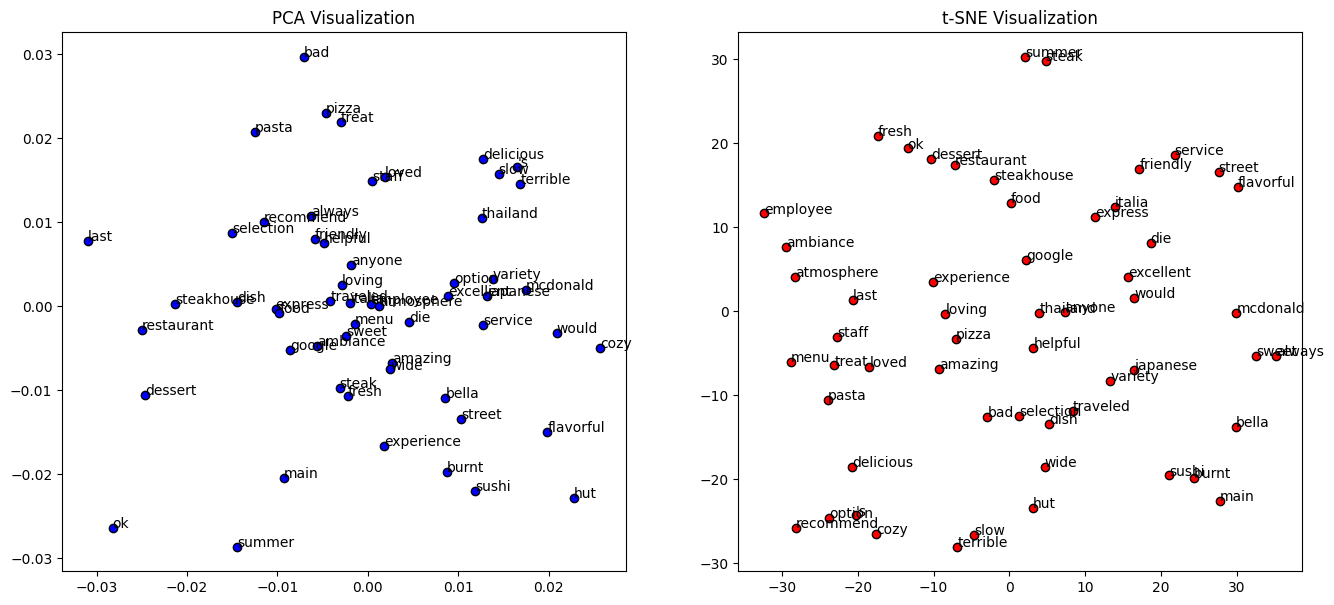

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_advanced_visualizations(model):
    labels = model.wv.index_to_key
    tokens = model.wv.vectors

    # PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(tokens)

    # t-SNE (perplexity must be lower than number of samples)
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(labels)-1))
    tsne_results = tsne.fit_transform(tokens)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Plot PCA
    ax1.scatter(pca_results[:, 0], pca_results[:, 1], c='blue', edgecolors='k')
    for i, txt in enumerate(labels):
        ax1.annotate(txt, (pca_results[i, 0], pca_results[i, 1]))
    ax1.set_title('PCA Visualization')

    # Plot t-SNE
    ax2.scatter(tsne_results[:, 0], tsne_results[:, 1], c='red', edgecolors='k')
    for i, txt in enumerate(labels):
        ax2.annotate(txt, (tsne_results[i, 0], tsne_results[i, 1]))
    ax2.set_title('t-SNE Visualization')

    plt.show()

plot_advanced_visualizations(w2v_bigram_model)